In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.validation import check_consistent_length
from sklearn.utils.extmath import stable_cumsum

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
from causalml.inference.tree import UpliftTreeClassifier, UpliftRandomForestClassifier
from causalml.inference.meta import BaseDRClassifier, BaseRClassifier, BaseSClassifier, BaseTClassifier, BaseXClassifier
from causalml.inference.iv import BaseDRIVRegressor
import optuna

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [2]:
import sys
print(sys.executable)

/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
def check_is_binary(array):
    if not np.all(np.unique(array) == np.array([0, 1])):
        raise ValueError(
            f'Input array is not binary. Got values {np.unique(array)}.'
        )
        
def principled_uplift_curve(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    desc_score_indices = np.argsort(uplift, kind='mergesort')[::-1]
    y_true = y_true[desc_score_indices]
    treatment = treatment[desc_score_indices]

    n_y1_t1 = np.zeros_like(y_true)
    n_y0_t0 = np.zeros_like(y_true)
    n_y1_t0 = np.zeros_like(y_true)
    n_y0_t1 = np.zeros_like(y_true)

    n_y1_t1[np.where((y_true == 1) & (treatment == 1))] = 1
    n_y0_t0[np.where((y_true == 0) & (treatment == 0))] = 1
    n_y1_t0[np.where((y_true == 1) & (treatment == 0))] = 1
    n_y0_t1[np.where((y_true == 0) & (treatment == 1))] = 1
    
    cum_y1_t1 = stable_cumsum(n_y1_t1)
    cum_y0_t0 = stable_cumsum(n_y0_t0)
    cum_y1_t0 = stable_cumsum(n_y1_t0)
    cum_y0_t1 = stable_cumsum(n_y0_t1)

    curve_values = cum_y1_t1 + cum_y0_t0 - cum_y1_t0 - cum_y0_t1
    return curve_values

def max_principled_uplift_curve(y_true, treatment):

    check_consistent_length(y_true, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    treatment = np.array(treatment)

    perfect_uplift = np.zeros_like(y_true)
    perfect_uplift[treatment == y_true] = 1

    return principled_uplift_curve(y_true, perfect_uplift, treatment)

def principled_uplift_auc_score(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    x_actual = np.array(range(len(y_true)))
    y_actual = principled_uplift_curve(y_true, uplift, treatment)
    y_perfect = max_principled_uplift_curve(y_true, treatment)

    x_baseline = np.array([0, x_actual[-1]])
    y_baseline = np.array([0, y_perfect[-1]])

    auc_baseline = auc(x_baseline, y_baseline)
    auc_perfect = auc(x_actual, y_perfect) - auc_baseline
    auc_actual = auc(x_actual, y_actual) - auc_baseline

    if auc_perfect == 0:
        return 0.0
    return auc_actual / auc_perfect


In [11]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):
    X_selected = X[selected_features]
    
    pred_c = model_c.predict_proba(X_selected)[:, 1]
    pred_t = model_t.predict_proba(X_selected)[:, 1]
    
    uplift_pred = pred_t - pred_c
    
    pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})
    auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
    puc = principled_uplift_auc_score(y, uplift_pred, treatment)
  
    print('AUUC:', auuc.squeeze())
    print('PUC:', puc)
    
    return uplift_pred, auuc, puc

In [12]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50, metrics='auuc'):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        if metrics == 'auuc':
            return auuc_val.item()
        
        elif metrics == 'puc':
            return puc_val


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

### Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling.

Авторы данной статьи предлагают двухстадийный подход к отбору фичей:

1. Первый этап - выделение релевантных признаков с помощью Bin-based Divergence Filters. (Из статьи Feature Selection Methods for Uplift Modeling and Heterogeneous Treatment Effect). К уже сущесствующим методам авторы предлагают еще два -
    1. UC filter - данные разбиваются на K Бинов на основе перцентилей значений признака. Для каждого Бина вычисляются - сумма значений целевой переменной в treatment группе для данного бина (фактически, количество положительных исходов в treatment); сумма значений целевой переменной в control группе для данного бина; количество наблюдений в treatment группе в данном бине;  количество наблюдений в control группе в данном бине. Итоговый score для признака F вычисляется как сумма uplift'ов по всем бинам, взвешенная на долю наблюдений в каждом бине. Высокое значение RSUC говорит о том, что признак хорошо разделяет данные на группы с разным uplift'ом. Такой признак потенциально важен для моделирования гетерогенности эффекта воздействия (CATE).
    2. AUUC filter использует параметрическую uplift-кривую для оценки важности признаков. Все наблюдения сортируются по возрастанию значения признака F. Для каждого t (количество первых наблюдений в отсортированном списке) строится точка на кривой. Функция кривой задается следующим образом: f(F_j, t) = (Y_t^T / N_t^T - Y_t^C / N_t^C) * (N_t^T + N_t^C), где Y_t^T - сумма исходов в treatment группе среди первых t наблюдений, N_t^T - количество наблюдений в treatment группе среди первых t наблюдений, Y_t^C - 	сумма исходов в control группе среди первых t наблюдений, N_t^C - количество наблюдений в control группе среди первых t наблюдений. Итоговый score для признака F - это площадь под построенной кривой. Высокое значение метрики говорит о том, что при сортировке по данному признаку, объекты с высокими значениями признака имеют систематически другой uplift, чем объекты с низкими значениями. Такой признак потенциально является хорошим модификатором эффекта воздействия.
2. Второй этап - анализ избыточности на отобранном наборе признаков. Начиная с первого по значимости признака в релевантном наборе, мы удаляем признаки с более низким рангом, коэффициент корреляции которых с ним превышает заданный параметр 𝜌₀. В данной работе параметр 𝜌₀ установлен равным 0.8.

Из библиотеки upliftml возьмем метод UpliftCurveFilter, он соотвествует второму предложенному в статье методу оценки признаков с помощью uplift-кривой:

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import auc

def rsaauuc_single_feature(
    x: pd.Series,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    df = pd.DataFrame({
        'x': x,
        'treatment': treatment,
        'y': y
    }).dropna()

    if df['x'].nunique() < 3:
        return 0.0

    try:
        df = df.sort_values('x')
        df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')
    except ValueError:
        return 0.0

    uplift_values = []

    for _, group in df.groupby('bin', observed=True):
        yt = group.loc[group.treatment == 1, 'y']
        yc = group.loc[group.treatment == 0, 'y']

        if len(yt) < 5 or len(yc) < 5:
            continue

        uplift_values.append(yt.mean() - yc.mean())

    if len(uplift_values) < 2:
        return 0.0

    return auc(np.arange(len(uplift_values)), uplift_values)

In [14]:
from tqdm import tqdm


def rsaauuc_feature_ranking(
    X: pd.DataFrame,
    treatment: pd.Series,
    y: pd.Series,
    n_bins=10
):
    scores = {}

    for col in tqdm(X.columns):
        scores[col] = rsaauuc_single_feature(
            X[col], treatment, y, n_bins=n_bins
        )

    return (
        pd.Series(scores)
        .sort_values(ascending=False)
    )

In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform


def redundancy_reduction(
    X: pd.DataFrame,
    scores: pd.Series,
    top_k=80,
    corr_threshold=0.85
):
    top_feats = scores.head(top_k).index.tolist()

    corr = X[top_feats].corr().abs()

    dist = 1 - corr
    condensed = squareform(dist.values)

    Z = linkage(condensed, method='average')

    clusters = fcluster(Z, t=1 - corr_threshold, criterion='distance')

    cluster_df = pd.DataFrame({
        'feature': top_feats,
        'cluster': clusters,
        'score': scores.loc[top_feats].values
    })

    selected = (
        cluster_df
        .sort_values('score', ascending=False)
        .groupby('cluster')
        .head(1)['feature']
        .tolist()
    )

    return selected, cluster_df

In [16]:
def get_features(
    X, treatment, y,
    n_bins=10,
    top_k=80,
    corr_threshold=0.80
):
    scores = rsaauuc_feature_ranking(
        X, treatment, y, n_bins=n_bins
    )

    selected, cluster_df = redundancy_reduction(
        X, scores,
        top_k=top_k,
        corr_threshold=corr_threshold
    )

    return selected, scores, cluster_df

In [17]:
 selected_features_v1, scores_v1, cluster_df_v1 = get_features(X_train, treatment_train, y_train)

100%|█████████████████████████████████████████| 193/193 [00:06<00:00, 29.17it/s]


In [18]:
len(selected_features_v1)

48

In [19]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, puc_train_v1, study_v1 = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                     y_train, X_val, treatment_val, 
                                                                                                     y_val, selected_features_v1)

[I 2026-04-27 22:30:57,322] A new study created in memory with name: no-name-fadafa11-315f-40f6-934e-8b5fbb3eb5ce
[I 2026-04-27 22:31:58,304] Trial 7 finished with value: 0.5808398641673227 and parameters: {'depth_c': 5, 'learning_rate_c': 0.029598190605139192, 'iterations_c': 963, 'l2_leaf_reg_c': 18.52298289431978, 'bagging_temperature_c': 2.6615427302148174, 'random_strength_c': 6.336848421430061, 'min_data_in_leaf_c': 35, 'depth_t': 4, 'learning_rate_t': 0.046680615412903824, 'iterations_t': 360, 'l2_leaf_reg_t': 17.141326231558057, 'bagging_temperature_t': 2.3849141880591262, 'random_strength_t': 5.832500373879341, 'min_data_in_leaf_t': 47}. Best is trial 7 with value: 0.5808398641673227.


AUUC: 0.5808398641673227
PUC: 0.01229657405116334


[I 2026-04-27 22:32:39,533] Trial 8 finished with value: 0.6605674882505822 and parameters: {'depth_c': 9, 'learning_rate_c': 0.019752284026685378, 'iterations_c': 703, 'l2_leaf_reg_c': 16.58959645232081, 'bagging_temperature_c': 8.08445149104054, 'random_strength_c': 5.136834858828786, 'min_data_in_leaf_c': 65, 'depth_t': 5, 'learning_rate_t': 0.21893251600071084, 'iterations_t': 478, 'l2_leaf_reg_t': 16.747989822825232, 'bagging_temperature_t': 0.49985999916540846, 'random_strength_t': 8.922529409052792, 'min_data_in_leaf_t': 72}. Best is trial 8 with value: 0.6605674882505822.


AUUC: 0.6605674882505822
PUC: 0.031994880917112264


[I 2026-04-27 22:32:41,217] Trial 9 finished with value: 0.670033995936164 and parameters: {'depth_c': 5, 'learning_rate_c': 0.07305900374727431, 'iterations_c': 457, 'l2_leaf_reg_c': 9.119750329509685, 'bagging_temperature_c': 3.543138517660156, 'random_strength_c': 3.0734507849603396, 'min_data_in_leaf_c': 18, 'depth_t': 6, 'learning_rate_t': 0.0361552967448217, 'iterations_t': 907, 'l2_leaf_reg_t': 13.454955605325926, 'bagging_temperature_t': 9.029949203552972, 'random_strength_t': 2.863084691047979, 'min_data_in_leaf_t': 37}. Best is trial 9 with value: 0.670033995936164.


...

AUUC: 0.6616645081266035
PUC: 0.03287143535221633


[I 2026-04-27 22:44:44,780] Trial 49 finished with value: 0.611562623784957 and parameters: {'depth_c': 6, 'learning_rate_c': 0.022436176564771027, 'iterations_c': 738, 'l2_leaf_reg_c': 17.054309331949806, 'bagging_temperature_c': 1.2848566396569758, 'random_strength_c': 1.6284631644821768, 'min_data_in_leaf_c': 56, 'depth_t': 5, 'learning_rate_t': 0.1104374360416437, 'iterations_t': 1105, 'l2_leaf_reg_t': 4.2066870005047186, 'bagging_temperature_t': 5.85105221044267, 'random_strength_t': 6.0935104091244385, 'min_data_in_leaf_t': 18}. Best is trial 42 with value: 0.7529857358436316.


AUUC: 0.611562623784957
PUC: 0.03113883389882163


[I 2026-04-27 22:44:45,297] Trial 48 finished with value: 0.6214222269949158 and parameters: {'depth_c': 6, 'learning_rate_c': 0.022378063819371106, 'iterations_c': 739, 'l2_leaf_reg_c': 17.201298012281633, 'bagging_temperature_c': 1.3610046861460607, 'random_strength_c': 1.3395772758542144, 'min_data_in_leaf_c': 58, 'depth_t': 5, 'learning_rate_t': 0.11837567971799287, 'iterations_t': 1233, 'l2_leaf_reg_t': 4.279906987895572, 'bagging_temperature_t': 5.848632516036502, 'random_strength_t': 8.453859353006255, 'min_data_in_leaf_t': 17}. Best is trial 42 with value: 0.7529857358436316.


AUUC: 0.6214222269949158
PUC: 0.02949766882547754
AUUC: 2.6896522170718167
PUC: 0.12804435621210616


In [20]:
uplift_pred_test_v1, auuc_test_v1, puc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features_v1)

AUUC: 0.6792198220148292
PUC: 0.0537179580906303


In [21]:
# 0.5764277840921775 - до оптуны

### Doubly Robust Adaptive LASSO for Effect

In [22]:
from catboost import CatBoostRegressor, CatBoostClassifier


def train_nuisance_models(X, T, y):
    mu1 = CatBoostRegressor(verbose=False, random_state=SEED)
    mu0 = CatBoostRegressor(verbose=False, random_state=SEED)
    e = CatBoostClassifier(verbose=False, random_state=SEED)

    mu1.fit(X[T==1], y[T==1])
    mu0.fit(X[T==0], y[T==0])
    e.fit(X, T)

    return mu1, mu0, e

In [23]:
def compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e):
    mu1_pred = mu1.predict(X)
    mu0_pred = mu0.predict(X)
    e_pred = np.clip(e.predict_proba(X)[:,1], 1e-3, 1-1e-3)

    tau_hat = (
        T * (y - mu1_pred) / e_pred
        - (1-T) * (y - mu0_pred) / (1 - e_pred)
        + mu1_pred - mu0_pred
    )

    return tau_hat

In [24]:
from sklearn.linear_model import Ridge

def initial_ridge_weights(X, tau_hat):
    ridge = Ridge(alpha=1.0, random_state=SEED)
    ridge.fit(X, tau_hat)
    return np.abs(ridge.coef_)

In [25]:
from sklearn.linear_model import Lasso

def adaptive_lasso(X, tau_hat, weights, alpha=0.01):
    X_scaled = X / (weights + 1e-6)

    lasso = Lasso(alpha=alpha, random_state=SEED)
    lasso.fit(X_scaled, tau_hat)

    beta = lasso.coef_ / (weights + 1e-6)

    return beta


In [26]:
def dr_adaptive_lasso_feature_selection(
    X, T, y,
    alpha=0.01
):
    mu1, mu0, e = train_nuisance_models(X, T, y)

    tau_hat = compute_dr_pseudo_outcome(X, T, y, mu1, mu0, e)

    weights = initial_ridge_weights(X, tau_hat)

    beta = adaptive_lasso(X, tau_hat, weights, alpha)

    selected_features = X.columns[np.abs(beta) > 1e-6].tolist()

    return selected_features, beta, tau_hat


In [27]:
selected_features_v2, beta, tau_hat = dr_adaptive_lasso_feature_selection(X_train, treatment_train, y_train, alpha=0.001)

In [28]:
len(selected_features_v2)

184

In [29]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, puc_train_v2, study_v2 = train_tlearner(BASE_MODEL,
                                                                                                     X_train, 
                                                                                                     treatment_train, 
                                                                                                     y_train, 
                                                                                                     X_val,
                                                                                                     treatment_val, 
                                                                                                     y_val,
                                                                                                     selected_features_v2)

[I 2026-04-27 22:46:32,145] A new study created in memory with name: no-name-45aa7d70-1986-414b-9039-e2d9790c2f1d
[I 2026-04-27 22:49:22,392] Trial 10 finished with value: 0.6342361275863223 and parameters: {'depth_c': 5, 'learning_rate_c': 0.05070133335264678, 'iterations_c': 714, 'l2_leaf_reg_c': 19.038927819620998, 'bagging_temperature_c': 4.528312777779844, 'random_strength_c': 0.13817589629297689, 'min_data_in_leaf_c': 9, 'depth_t': 6, 'learning_rate_t': 0.04319265611289412, 'iterations_t': 369, 'l2_leaf_reg_t': 9.483499408706157, 'bagging_temperature_t': 0.8726684295246434, 'random_strength_t': 7.356787420171999, 'min_data_in_leaf_t': 27}. Best is trial 10 with value: 0.6342361275863223.


AUUC: 0.6342361275863223
PUC: 0.0065065340041387636


[I 2026-04-27 22:49:52,667] Trial 11 finished with value: 0.6153839925912216 and parameters: {'depth_c': 5, 'learning_rate_c': 0.02770665925948528, 'iterations_c': 853, 'l2_leaf_reg_c': 5.039580991059201, 'bagging_temperature_c': 4.326919938316526, 'random_strength_c': 7.06832850165951, 'min_data_in_leaf_c': 11, 'depth_t': 5, 'learning_rate_t': 0.1371265537270046, 'iterations_t': 469, 'l2_leaf_reg_t': 15.696369137645625, 'bagging_temperature_t': 2.7497483161348644, 'random_strength_t': 4.979184964614182, 'min_data_in_leaf_t': 28}. Best is trial 10 with value: 0.6342361275863223.


AUUC: 0.6153839925912216
PUC: 0.03139897001234758


[I 2026-04-27 22:50:16,594] Trial 3 finished with value: 0.6291650746550868 and parameters: {'depth_c': 4, 'learning_rate_c': 0.03266631900518025, 'iterations_c': 964, 'l2_leaf_reg_c': 10.555051490632193, 'bagging_temperature_c': 1.8673346450969186, 'random_strength_c': 5.79153676122004, 'min_data_in_leaf_c': 93, 'depth_t': 4, 'learning_rate_t': 0.28183320603212947, 'iterations_t': 644, 'l2_leaf_reg_t': 16.543841674063703, 'bagging_temperature_t': 2.9440756872844176, 'random_strength_t': 2.3291652301563026, 'min_data_in_leaf_t': 48}. Best is trial 10 with value: 0.6342361275863223.


...

AUUC: 0.7017150123184304
PUC: 0.026655454003976217


[I 2026-04-27 23:36:44,182] Trial 48 finished with value: 0.7149589826412852 and parameters: {'depth_c': 8, 'learning_rate_c': 0.15236654075134212, 'iterations_c': 365, 'l2_leaf_reg_c': 3.066394247141294, 'bagging_temperature_c': 8.617804789671247, 'random_strength_c': 8.469000806593879, 'min_data_in_leaf_c': 28, 'depth_t': 9, 'learning_rate_t': 0.014016034651275164, 'iterations_t': 968, 'l2_leaf_reg_t': 8.30243117659587, 'bagging_temperature_t': 9.888973243543285, 'random_strength_t': 1.512257420968875, 'min_data_in_leaf_t': 10}. Best is trial 22 with value: 0.833722598830318.


AUUC: 0.7149589826412852
PUC: 0.017205148734166956


[I 2026-04-27 23:36:47,928] Trial 49 finished with value: 0.6559723828418453 and parameters: {'depth_c': 8, 'learning_rate_c': 0.14837543036089956, 'iterations_c': 386, 'l2_leaf_reg_c': 3.002204340255743, 'bagging_temperature_c': 8.725883199001899, 'random_strength_c': 8.596744018237386, 'min_data_in_leaf_c': 28, 'depth_t': 9, 'learning_rate_t': 0.015100692530618685, 'iterations_t': 984, 'l2_leaf_reg_t': 3.368775041615823, 'bagging_temperature_t': 9.651693791872885, 'random_strength_t': 1.5414834002829672, 'min_data_in_leaf_t': 10}. Best is trial 22 with value: 0.833722598830318.


AUUC: 0.6559723828418453
PUC: 0.027428296731428284
AUUC: 2.06711343393123
PUC: 0.11870890768094641


In [30]:
uplift_pred_test_v2, auuc_test_v2, puc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, 
                                               selected_features_v2)

AUUC: 0.7066370425673701
PUC: 0.06062068856576168


In [31]:
# до оптуны метрика была выше - 0.6668880309490919

### A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection

Код реализован в библиотеке kuplift - https://github.com/UData-Orange/kuplift/blob/main/kuplift/feature_selection.py

Для ускорения работы отберем признаки на валидационной выборке

In [32]:
import kuplift as kp

In [33]:
fs = kp.FeatureSelection()

important_vars = fs.filter(
    X_val,
    treatment_val,
    y_val
)

In [34]:
important_vars

{'gender': 0,
 'promo_share_15d': 3.485882970737384e-05,
 'k_var_sku_price_1m_g26': 3.969220190779956e-05,
 'k_var_sku_price_3m_g24': 3.973858593423515e-05,
 'mean_discount_depth_15d': 4.0548634555479084e-05,
 'sale_sum_12m_g26': 4.297170548488893e-05,
 'k_var_sku_price_1m_g54': 4.331536845124712e-05,
 'disc_sum_6m_g34': 4.3543643487371094e-05,
 'k_var_sku_price_3m_g33': 4.428677536220568e-05,
 'k_var_disc_share_1m_g49': 4.5032289431259245e-05,
 'k_var_count_per_cheque_3m_g24': 4.582397830270521e-05,
 'sale_sum_3m_g33': 4.59610954334403e-05,
 'k_var_count_per_cheque_6m_g24': 4.604826990506511e-05,
 'k_var_sku_price_1m_g40': 4.730351463399946e-05,
 'k_var_count_per_cheque_15d_g34': 4.7396768259551914e-05,
 'k_var_sku_price_6m_g41': 4.7548803476762865e-05,
 'sale_count_6m_g32': 4.755212611006628e-05,
 'k_var_sku_price_3m_g54': 4.779033158926403e-05,
 'k_var_sku_price_3m_g32': 4.80703186608137e-05,
 'k_var_cheque_15d': 4.8244707873699545e-05,
 'k_var_sku_price_1m_g49': 4.854045578555415e-

In [35]:
len(important_vars)

193

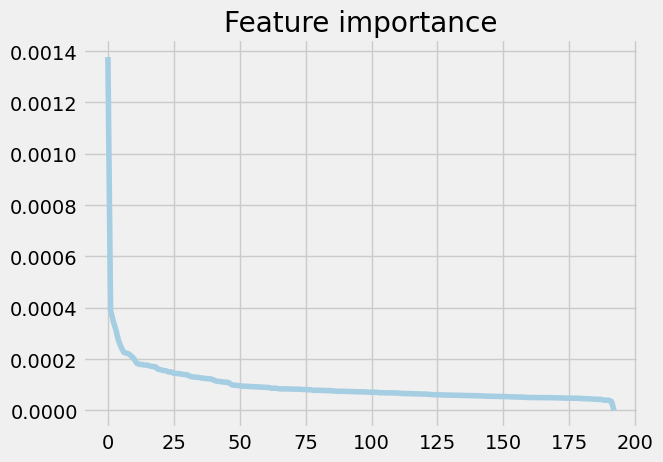

In [36]:
scores = sorted(important_vars.values(), reverse=True)

plt.plot(scores)
plt.title('Feature importance')
plt.show()

In [37]:
def find_elbow(scores_dict):
    scores = np.array(sorted(scores_dict.values(), reverse=True))

    x = np.arange(len(scores))
    y = scores

    line_start = np.array([0, y[0]])
    line_end = np.array([len(scores)-1, y[-1]])

    line_vec = line_end - line_start
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for i in range(len(scores)):
        point = np.array([i, y[i]])
        vec = point - line_start
        proj = np.dot(vec, line_vec_norm) * line_vec_norm
        dist = np.linalg.norm(vec - proj)
        distances.append(dist)

    elbow_idx = np.argmax(distances)
    return elbow_idx + 1

optimal_features = find_elbow(important_vars)
print(f'Оптимальное количество признаков по локтю: {optimal_features}')

Оптимальное количество признаков по локтю: 12


In [38]:
scores_series = pd.Series(important_vars).sort_values(ascending=False)
top_features = scores_series.head(optimal_features).index.tolist()

In [39]:
top_features

['perdelta_days_between_visits_15_30d',
 'cheque_count_6m_g25',
 'k_var_cheque_group_width_15d',
 'k_var_days_between_visits_15d',
 'sale_count_12m_g49',
 'cheque_count_6m_g32',
 'sale_count_12m_g54',
 'response_sms',
 'cheque_count_6m_g20',
 'cheque_count_12m_g57',
 'k_var_count_per_cheque_6m_g44',
 'crazy_purchases_cheque_count_12m']

In [40]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, puc_train_v3, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train, X_val, treatment_val, 
                                                                                                  y_val, top_features)

[I 2026-04-28 00:05:35,619] A new study created in memory with name: no-name-087c319d-9e47-42b4-9d6a-fcebde5d04c0
[I 2026-04-28 00:06:45,858] Trial 4 finished with value: 0.5478968670622516 and parameters: {'depth_c': 9, 'learning_rate_c': 0.020418948994765724, 'iterations_c': 1167, 'l2_leaf_reg_c': 9.243302082719568, 'bagging_temperature_c': 8.833867538900373, 'random_strength_c': 6.154769101812988, 'min_data_in_leaf_c': 45, 'depth_t': 4, 'learning_rate_t': 0.07213987169929359, 'iterations_t': 492, 'l2_leaf_reg_t': 19.411257190190323, 'bagging_temperature_t': 2.321402082829466, 'random_strength_t': 9.861368062276327, 'min_data_in_leaf_t': 32}. Best is trial 4 with value: 0.5478968670622516.


AUUC: 0.5478968670622516
PUC: 0.014610923356151183


[I 2026-04-28 00:07:02,360] Trial 12 finished with value: 0.7196338795206456 and parameters: {'depth_c': 7, 'learning_rate_c': 0.045297659910957834, 'iterations_c': 1022, 'l2_leaf_reg_c': 16.517072973110473, 'bagging_temperature_c': 9.723954581500045, 'random_strength_c': 0.5022924985850374, 'min_data_in_leaf_c': 46, 'depth_t': 4, 'learning_rate_t': 0.010570557552187903, 'iterations_t': 1032, 'l2_leaf_reg_t': 18.508451294362196, 'bagging_temperature_t': 7.404228689572471, 'random_strength_t': 3.615797049950137, 'min_data_in_leaf_t': 33}. Best is trial 12 with value: 0.7196338795206456.
[I 2026-04-28 00:07:02,504] Trial 8 finished with value: 0.5385685998678273 and parameters: {'depth_c': 5, 'learning_rate_c': 0.011398255610102645, 'iterations_c': 1282, 'l2_leaf_reg_c': 14.370076766833908, 'bagging_temperature_c': 3.5356299060251706, 'random_strength_c': 5.904595007483407, 'min_data_in_leaf_c': 15, 'depth_t': 5, 'learning_rate_t': 0.07446456357433635, 'iterations_t': 929, 'l2_leaf_reg_t

AUUC: 0.7196338795206456
PUC: -0.006748333423188339
AUUC: 0.5385685998678273
PUC: 0.024729154353803556


[I 2026-04-28 00:07:03,343] Trial 1 finished with value: 0.42324434955711726 and parameters: {'depth_c': 10, 'learning_rate_c': 0.010159719834849397, 'iterations_c': 692, 'l2_leaf_reg_c': 4.712429538734434, 'bagging_temperature_c': 4.9530553277197455, 'random_strength_c': 3.3917968773695994, 'min_data_in_leaf_c': 52, 'depth_t': 5, 'learning_rate_t': 0.19178477243307082, 'iterations_t': 916, 'l2_leaf_reg_t': 18.103666861238015, 'bagging_temperature_t': 8.410552016733712, 'random_strength_t': 9.204776356588901, 'min_data_in_leaf_t': 8}. Best is trial 12 with value: 0.7196338795206456.


...

AUUC: 0.5604491517401277
PUC: 0.015991352163354424


[I 2026-04-28 00:11:57,973] Trial 45 finished with value: 0.6922103977153993 and parameters: {'depth_c': 6, 'learning_rate_c': 0.29581016517103564, 'iterations_c': 1355, 'l2_leaf_reg_c': 16.30856068782374, 'bagging_temperature_c': 9.956176456762815, 'random_strength_c': 9.170991654392642, 'min_data_in_leaf_c': 40, 'depth_t': 4, 'learning_rate_t': 0.014529459293184357, 'iterations_t': 1018, 'l2_leaf_reg_t': 19.80432980724621, 'bagging_temperature_t': 4.929160630832293, 'random_strength_t': 4.866094516497223, 'min_data_in_leaf_t': 20}. Best is trial 7 with value: 0.7517574747195531.


AUUC: 0.6922103977153993
PUC: 0.01504045036353822


[I 2026-04-28 00:11:58,977] Trial 47 finished with value: 0.6535031929236941 and parameters: {'depth_c': 6, 'learning_rate_c': 0.1307775006212729, 'iterations_c': 1352, 'l2_leaf_reg_c': 7.115494625797795, 'bagging_temperature_c': 9.997640727913302, 'random_strength_c': 9.03458440514615, 'min_data_in_leaf_c': 40, 'depth_t': 4, 'learning_rate_t': 0.03898955843226309, 'iterations_t': 1063, 'l2_leaf_reg_t': 19.674129935082448, 'bagging_temperature_t': 4.778675028611034, 'random_strength_t': 5.331288273426495, 'min_data_in_leaf_t': 14}. Best is trial 7 with value: 0.7517574747195531.


AUUC: 0.6535031929236941
PUC: 0.019514818245042222
AUUC: 7.5779047402930475
PUC: 0.1759466923426762


In [41]:
uplift_pred_test_v3, auuc_test_v3, puc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, top_features)

AUUC: 0.7287594933797058
PUC: 0.03574712507586364


In [42]:
# попробуем взять топ-50 фичей
top_features_v2 = scores_series.head(50).index.tolist()
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, puc_train_v4, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train, X_val, treatment_val, 
                                                                                                  y_val, top_features_v2)

[I 2026-04-28 00:12:20,678] A new study created in memory with name: no-name-08408961-1371-49be-9b04-f4acbbca5a6a
[I 2026-04-28 00:14:04,137] Trial 11 finished with value: 0.6385973145583448 and parameters: {'depth_c': 7, 'learning_rate_c': 0.06635386167035145, 'iterations_c': 564, 'l2_leaf_reg_c': 13.800577779821841, 'bagging_temperature_c': 6.591234688992458, 'random_strength_c': 9.418649701936634, 'min_data_in_leaf_c': 80, 'depth_t': 8, 'learning_rate_t': 0.1549623059567313, 'iterations_t': 439, 'l2_leaf_reg_t': 19.26925884377736, 'bagging_temperature_t': 9.178020049073067, 'random_strength_t': 2.2732418830091214, 'min_data_in_leaf_t': 90}. Best is trial 11 with value: 0.6385973145583448.


AUUC: 0.6385973145583448
PUC: 0.015066210300079683


[I 2026-04-28 00:14:06,843] Trial 8 finished with value: 0.6749857777079533 and parameters: {'depth_c': 4, 'learning_rate_c': 0.14375221314284795, 'iterations_c': 888, 'l2_leaf_reg_c': 12.944232182350934, 'bagging_temperature_c': 9.331625816171623, 'random_strength_c': 9.711559200566954, 'min_data_in_leaf_c': 55, 'depth_t': 5, 'learning_rate_t': 0.010558758047910377, 'iterations_t': 570, 'l2_leaf_reg_t': 7.6360722867916575, 'bagging_temperature_t': 2.0995172072360813, 'random_strength_t': 6.474958598564466, 'min_data_in_leaf_t': 84}. Best is trial 8 with value: 0.6749857777079533.


AUUC: 0.6749857777079533
PUC: -0.02591574608387715


[I 2026-04-28 00:14:49,414] Trial 12 finished with value: 0.713215898795936 and parameters: {'depth_c': 7, 'learning_rate_c': 0.15739448320046182, 'iterations_c': 526, 'l2_leaf_reg_c': 7.351718664461874, 'bagging_temperature_c': 5.081601485346562, 'random_strength_c': 1.1502134255027474, 'min_data_in_leaf_c': 75, 'depth_t': 7, 'learning_rate_t': 0.2716128235981386, 'iterations_t': 837, 'l2_leaf_reg_t': 15.15720684703187, 'bagging_temperature_t': 3.2822441062593533, 'random_strength_t': 7.443969702248049, 'min_data_in_leaf_t': 29}. Best is trial 12 with value: 0.713215898795936.


...

AUUC: 0.5854375875573202
PUC: 0.04863883509438947


[I 2026-04-28 00:28:04,540] Trial 48 finished with value: 0.6684800414795714 and parameters: {'depth_c': 8, 'learning_rate_c': 0.20664499053367302, 'iterations_c': 1350, 'l2_leaf_reg_c': 1.0085280674000368, 'bagging_temperature_c': 2.8828042864235863, 'random_strength_c': 5.961705075695685, 'min_data_in_leaf_c': 65, 'depth_t': 6, 'learning_rate_t': 0.03874767090070346, 'iterations_t': 1483, 'l2_leaf_reg_t': 14.360033613119912, 'bagging_temperature_t': 3.2236218289188123, 'random_strength_t': 0.49415353047824995, 'min_data_in_leaf_t': 50}. Best is trial 28 with value: 0.7891300409956338.


AUUC: 0.6684800414795714
PUC: 0.04930806884076924


[I 2026-04-28 00:28:06,845] Trial 49 finished with value: 0.6289806399882188 and parameters: {'depth_c': 8, 'learning_rate_c': 0.214976296062615, 'iterations_c': 1366, 'l2_leaf_reg_c': 2.086871893335273, 'bagging_temperature_c': 2.830640229534407, 'random_strength_c': 6.23949729257195, 'min_data_in_leaf_c': 50, 'depth_t': 7, 'learning_rate_t': 0.03779601044012405, 'iterations_t': 1426, 'l2_leaf_reg_t': 14.116670625043424, 'bagging_temperature_t': 6.4569968551223536, 'random_strength_t': 0.5959469216652131, 'min_data_in_leaf_t': 51}. Best is trial 28 with value: 0.7891300409956338.


AUUC: 0.6289806399882188
PUC: 0.04767633516452155
AUUC: 8.831432329846491
PUC: 0.2721537647296102


In [43]:
uplift_pred_test_v4, auuc_test_v4, puc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, top_features_v2)

AUUC: 0.5076963518124076
PUC: 0.018837304536869576


### Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization

In [44]:
class RUAD_AUUC_Selector:
    def __init__(self, hidden_dim=128, epochs=50, lr=1e-3, top_k=30, device='cpu'):
        
        self.hidden_dim = hidden_dim
        self.epochs = epochs
        self.lr = lr
        self.top_k = top_k
        self.device = device

    def _create_joint_label(self, t, y):
        
        return t * 2 + y

    def _compute_uplift(self, probs):
  
        p_y1_t0 = probs[:,1] / (probs[:,0]+probs[:,1]+1e-8)
        p_y1_t1 = probs[:,3] / (probs[:,2]+probs[:,3]+1e-8)
        tau_hat = p_y1_t1 - p_y1_t0
        return tau_hat

    def _auuc_per_feature(self, X, uplift):
        
        N, d = X.shape
        scores = []
        for i in range(d):
            order = np.argsort(X[:,i])
            uplift_sorted = uplift[order]
            if len(uplift_sorted) < 2:
                scores.append(0)
            else:
                scores.append(auc(np.arange(len(uplift_sorted)), uplift_sorted))
        return np.array(scores)

    def fit(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns
            X_train_np = X_train.values
            X_val_np = X_val.values
        else:
            self.feature_names = np.arange(X_train.shape[1])
            X_train_np = X_train
            X_val_np = X_val

        d = X_train_np.shape[1]

        X_tensor = torch.tensor(X_train_np, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(self._create_joint_label(t_train, y_train), dtype=torch.long).to(self.device)

        self.model = nn.Sequential(
            nn.Linear(d, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        losses = []
        auuc_history = []

        for epoch in range(self.epochs):
    
            logits = self.model(X_tensor)
            loss = criterion(logits, y_tensor)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                probs_val = torch.softmax(self.model(torch.tensor(X_val_np, dtype=torch.float32).to(self.device)), dim=1).cpu().numpy()
            
            uplift_val = self._compute_uplift(probs_val)
            auuc_epoch = self._auuc_per_feature(X_val_np, uplift_val)
            auuc_history.append(auuc_epoch)

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('RUAD Training Loss')
            plt.grid(True)
            plt.show()

        self.importance_ = np.mean(auuc_history, axis=0)
        idx = np.argsort(self.importance_)[-self.top_k:]
        self.selected_idx_ = idx
        self.selected_features_ = self.feature_names[idx]

        return self

    def transform(self, X):
        
        if isinstance(X, pd.DataFrame):
            return X[self.selected_features_]
        return X[:, self.selected_idx_]
    
    def fit_transform(self, X_train, t_train, y_train, X_val, t_val, y_val):
        
        self.fit(X_train, t_train, y_train, X_val, t_val, y_val)
        return self.transform(X_train)

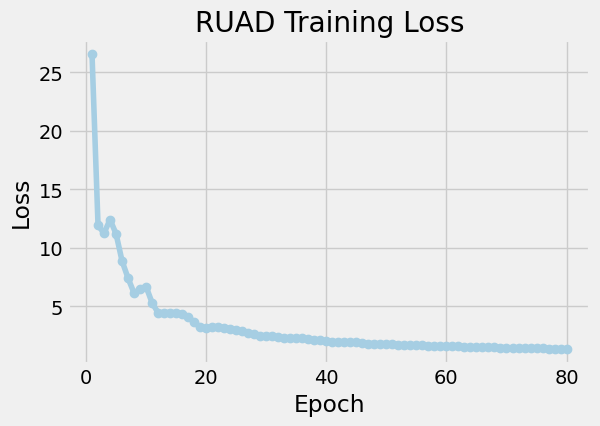

In [45]:
selector = RUAD_AUUC_Selector(hidden_dim=128, epochs=80, lr=1e-3, top_k=50)
X_selected = selector.fit_transform(X_train, treatment_train, y_train, X_val, treatment_val, y_val)

In [46]:
print('Число отобранных признако:', len(selector.selected_features_))

Число отобранных признако: 50


In [47]:
selected_features_v5 = X_selected.columns.tolist()

In [48]:
model_t_v5, model_c_v5, uplift_pred_train_v5, auuc_train_v5, puc_train_v5, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train, X_val, treatment_val, 
                                                                                                  y_val, selected_features_v5)

[I 2026-04-28 00:30:07,528] A new study created in memory with name: no-name-7928c27c-066d-4c15-8117-fb6d2ce7e872
[I 2026-04-28 00:31:20,417] Trial 9 finished with value: 0.6295900251236036 and parameters: {'depth_c': 8, 'learning_rate_c': 0.010349516333595158, 'iterations_c': 419, 'l2_leaf_reg_c': 12.531641626507986, 'bagging_temperature_c': 8.72186333128364, 'random_strength_c': 4.756253594100123, 'min_data_in_leaf_c': 93, 'depth_t': 4, 'learning_rate_t': 0.12446733759505864, 'iterations_t': 447, 'l2_leaf_reg_t': 9.472446104470981, 'bagging_temperature_t': 3.868044737073882, 'random_strength_t': 5.0193593458870955, 'min_data_in_leaf_t': 84}. Best is trial 9 with value: 0.6295900251236036.


AUUC: 0.6295900251236036
PUC: 0.05448775018773619


[I 2026-04-28 00:31:53,625] Trial 11 finished with value: 0.5307269805868184 and parameters: {'depth_c': 7, 'learning_rate_c': 0.19869763829448325, 'iterations_c': 600, 'l2_leaf_reg_c': 18.306705272104743, 'bagging_temperature_c': 7.896787647177542, 'random_strength_c': 6.972702269382019, 'min_data_in_leaf_c': 72, 'depth_t': 5, 'learning_rate_t': 0.08038847040288047, 'iterations_t': 673, 'l2_leaf_reg_t': 16.716349678298922, 'bagging_temperature_t': 7.34764751084667, 'random_strength_t': 4.0057278065038115, 'min_data_in_leaf_t': 73}. Best is trial 9 with value: 0.6295900251236036.


AUUC: 0.5307269805868184
PUC: 0.016117799606855707


[I 2026-04-28 00:32:08,252] Trial 7 finished with value: 0.6311998165898343 and parameters: {'depth_c': 6, 'learning_rate_c': 0.03291303392777612, 'iterations_c': 789, 'l2_leaf_reg_c': 3.748936205212757, 'bagging_temperature_c': 5.615360475878629, 'random_strength_c': 6.199192912204995, 'min_data_in_leaf_c': 97, 'depth_t': 4, 'learning_rate_t': 0.0191788023723689, 'iterations_t': 828, 'l2_leaf_reg_t': 6.770402857020699, 'bagging_temperature_t': 9.982668022162843, 'random_strength_t': 0.9076485243035826, 'min_data_in_leaf_t': 9}. Best is trial 7 with value: 0.6311998165898343.


...

AUUC: 0.5636501344078038
PUC: 0.004880619838498328


[I 2026-04-28 00:45:43,064] Trial 49 finished with value: 0.5604950798275636 and parameters: {'depth_c': 5, 'learning_rate_c': 0.08487356778059177, 'iterations_c': 1484, 'l2_leaf_reg_c': 4.839691501759474, 'bagging_temperature_c': 1.6897023001670557, 'random_strength_c': 2.0751820771910494, 'min_data_in_leaf_c': 36, 'depth_t': 9, 'learning_rate_t': 0.022088066966162608, 'iterations_t': 697, 'l2_leaf_reg_t': 14.51994291424968, 'bagging_temperature_t': 7.073204679670986, 'random_strength_t': 1.8089839385823703, 'min_data_in_leaf_t': 58}. Best is trial 29 with value: 0.7205719756966764.


AUUC: 0.5604950798275636
PUC: 0.009332150753591492


[I 2026-04-28 00:45:50,640] Trial 46 finished with value: 0.40582526550638764 and parameters: {'depth_c': 5, 'learning_rate_c': 0.027536617869737833, 'iterations_c': 951, 'l2_leaf_reg_c': 4.3821591244732545, 'bagging_temperature_c': 1.5236234867829863, 'random_strength_c': 1.6445537194019766, 'min_data_in_leaf_c': 80, 'depth_t': 9, 'learning_rate_t': 0.10815727446470534, 'iterations_t': 1333, 'l2_leaf_reg_t': 14.955269864098021, 'bagging_temperature_t': 7.686381968778414, 'random_strength_t': 8.83662437655139, 'min_data_in_leaf_t': 75}. Best is trial 29 with value: 0.7205719756966764.


AUUC: 0.40582526550638764
PUC: 0.000977119517911861
AUUC: 5.637390978396371
PUC: 0.16163906780097478


In [49]:
uplift_pred_test_v5, auuc_test_v5, puc_test_v5 = get_uplift(model_t_v5, model_c_v5, X_test, treatment_test, y_test, selected_features_v5)

AUUC: 0.44619057635270853
PUC: -0.00040712388623998126


### Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling

In [50]:
class CausalFeatureSelector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.mask = nn.Parameter(torch.ones(input_dim))

    def forward(self, x):

        mask = torch.sigmoid(self.mask)

        return x * mask

class MCDWModel(nn.Module):

    def __init__(self, input_dim, hidden=128, heads=5):

        super().__init__()

        self.selector = CausalFeatureSelector(input_dim)

        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.heads = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(heads)
        ])

    def forward(self, x):

        x = self.selector(x)

        h = self.backbone(x)

        preds = torch.cat([head(h) for head in self.heads], dim=1)

        return preds

class MCDWFeatureSelector:

    def __init__(
        self,
        hidden=128,
        heads=5,
        epochs=50,
        lr=1e-3,
        lambda_l1=1e-3,
        device='cpu'
    ):

        self.hidden = hidden
        self.heads = heads
        self.epochs = epochs
        self.lr = lr
        self.lambda_l1 = lambda_l1
        self.device = device


    def fit(self, X, t, y):

        if isinstance(X, pd.DataFrame):

            self.feature_names = X.columns
            X = X.values

        else:

            self.feature_names = np.arange(X.shape[1])

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y, dtype=torch.float32).to(self.device)
        t_tensor = torch.tensor(t, dtype=torch.float32).to(self.device)

        input_dim = X.shape[1]

        self.model = MCDWModel(input_dim, self.hidden, self.heads).to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        losses = []

        for epoch in range(self.epochs):

            preds = self.model(X_tensor)

            target = y_tensor * (2 * t_tensor - 1)

            mse = ((preds - target.unsqueeze(1)) ** 2).mean()

            mask = torch.sigmoid(self.model.selector.mask)

            l1 = mask.abs().mean()

            loss = mse + self.lambda_l1 * l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(range(1, len(losses)+1), losses, marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('MCDW Training Loss')
            plt.grid(True)
            plt.show()

        mask_values = torch.sigmoid(self.model.selector.mask).detach().cpu().numpy()

        self.importance_ = mask_values

        return self


    def get_feature_importance(self):
        
        return pd.Series(self.importance_, index=self.feature_names).sort_values(ascending=False)


    def select_top_k(self, k):

        imp = self.get_feature_importance()
        return imp.head(k).index.tolist()


    def transform(self, X, k):

        features = self.select_top_k(k)

        if isinstance(X, pd.DataFrame):
            return X[features]

        else:
            idx = [np.where(self.feature_names == f)[0][0] for f in features]

            return X[:, idx]

In [51]:
selector = MCDWFeatureSelector(
    hidden=256,
    heads=5,
    epochs=30,
    lr=1e-3
)


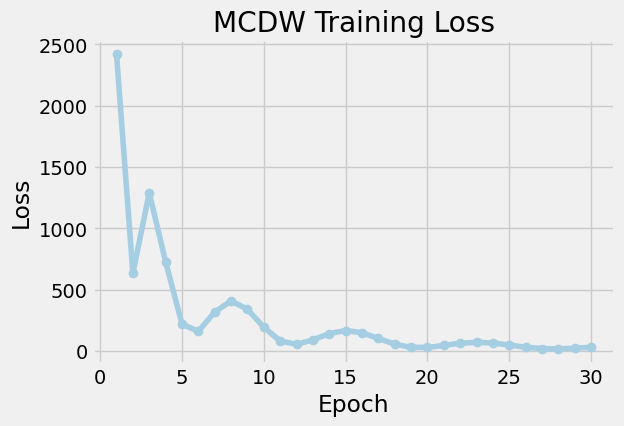

In [52]:
selector.fit(X_train, treatment_train, y_train)

In [53]:
importance = selector.get_feature_importance()

In [54]:
top_50_features = selector.select_top_k(50)

In [55]:
top_30_features = selector.select_top_k(30)

In [56]:
top_80_features = selector.select_top_k(80)

In [57]:
top_50_features

['k_var_sku_price_3m_g48',
 'cheque_count_6m_g32',
 'k_var_disc_share_3m_g41',
 'sale_count_12m_g54',
 'k_var_disc_share_1m_g34',
 'cheque_count_3m_g42',
 'cheque_count_6m_g45',
 'cheque_count_12m_g41',
 'sale_count_6m_g24',
 'k_var_sku_price_3m_g54',
 'crazy_purchases_cheque_count_3m',
 'mean_discount_depth_15d',
 'crazy_purchases_cheque_count_12m',
 'cheque_count_6m_g52',
 'k_var_sku_price_6m_g41',
 'cheque_count_12m_g56',
 'cheque_count_12m_g46',
 'cheque_count_6m_g56',
 'sale_count_12m_g33',
 'k_var_discount_depth_15d',
 'gender',
 'cheque_count_12m_g42',
 'k_var_sku_price_1m_g44',
 'k_var_sku_per_cheque_15d',
 'cheque_count_12m_g20',
 'cheque_count_6m_g79',
 'cheque_count_6m_g40',
 'k_var_days_between_visits_15d',
 'cheque_count_12m_g38',
 'cheque_count_6m_g25',
 'cheque_count_6m_g42',
 'k_var_sku_price_1m_g26',
 'children',
 'cheque_count_12m_g57',
 'cheque_count_12m_g39',
 'sale_count_6m_g44',
 'stdev_discount_depth_15d',
 'k_var_sku_price_1m_g54',
 'cheque_count_3m_g56',
 'cheq

In [58]:
model_t_v6, model_c_v6, uplift_pred_train_v6, auuc_train_v6, puc_train_v6, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train, X_val, treatment_val, 
                                                                                                  y_val, top_30_features)

[I 2026-04-28 00:46:54,857] A new study created in memory with name: no-name-82054b81-49e2-439f-917f-c2a977bdb68d
[I 2026-04-28 00:47:35,520] Trial 9 finished with value: 0.6263974323909784 and parameters: {'depth_c': 7, 'learning_rate_c': 0.025347735991086938, 'iterations_c': 303, 'l2_leaf_reg_c': 4.857120255393101, 'bagging_temperature_c': 9.985680812486779, 'random_strength_c': 9.305014187405543, 'min_data_in_leaf_c': 75, 'depth_t': 4, 'learning_rate_t': 0.17101000445144698, 'iterations_t': 343, 'l2_leaf_reg_t': 9.481230439611775, 'bagging_temperature_t': 4.719586018132283, 'random_strength_t': 1.3350975507581997, 'min_data_in_leaf_t': 92}. Best is trial 9 with value: 0.6263974323909784.


AUUC: 0.6263974323909784
PUC: 0.042336563169865345


[I 2026-04-28 00:47:54,056] Trial 0 finished with value: 0.6263387703848357 and parameters: {'depth_c': 6, 'learning_rate_c': 0.014096986038123196, 'iterations_c': 512, 'l2_leaf_reg_c': 3.5396072167112056, 'bagging_temperature_c': 3.6405079059600434, 'random_strength_c': 6.840301071584487, 'min_data_in_leaf_c': 38, 'depth_t': 7, 'learning_rate_t': 0.021544615681112333, 'iterations_t': 404, 'l2_leaf_reg_t': 7.876806716030387, 'bagging_temperature_t': 2.0750136290988683, 'random_strength_t': 6.395517577319046, 'min_data_in_leaf_t': 25}. Best is trial 9 with value: 0.6263974323909784.


AUUC: 0.6263387703848357
PUC: 0.0536819349709005


[I 2026-04-28 00:48:04,432] Trial 4 finished with value: 0.44941285595856695 and parameters: {'depth_c': 4, 'learning_rate_c': 0.2383299218479724, 'iterations_c': 479, 'l2_leaf_reg_c': 11.276221231764557, 'bagging_temperature_c': 0.18309876336771946, 'random_strength_c': 2.3195871869660225, 'min_data_in_leaf_c': 73, 'depth_t': 6, 'learning_rate_t': 0.011625427938995835, 'iterations_t': 562, 'l2_leaf_reg_t': 4.356960629014684, 'bagging_temperature_t': 5.492612329404844, 'random_strength_t': 7.207812229848221, 'min_data_in_leaf_t': 58}. Best is trial 9 with value: 0.6263974323909784.


...

AUUC: 0.6444517214266333
PUC: 0.00383512805236928


[I 2026-04-28 00:56:01,869] Trial 47 finished with value: 0.6235695540748928 and parameters: {'depth_c': 9, 'learning_rate_c': 0.012776414827287927, 'iterations_c': 514, 'l2_leaf_reg_c': 12.201181825085923, 'bagging_temperature_c': 0.10271045565268988, 'random_strength_c': 9.01682745252612, 'min_data_in_leaf_c': 38, 'depth_t': 8, 'learning_rate_t': 0.18708042217295248, 'iterations_t': 1240, 'l2_leaf_reg_t': 17.176142354332438, 'bagging_temperature_t': 0.059567056415328, 'random_strength_t': 0.10884253274280786, 'min_data_in_leaf_t': 65}. Best is trial 44 with value: 0.7198691849655457.


AUUC: 0.6235695540748928
PUC: 0.018790598850196454


[I 2026-04-28 00:56:03,294] Trial 46 finished with value: 0.4472960409636958 and parameters: {'depth_c': 9, 'learning_rate_c': 0.012716812196891171, 'iterations_c': 677, 'l2_leaf_reg_c': 12.225159286653033, 'bagging_temperature_c': 0.7196410401443022, 'random_strength_c': 5.538685500258934, 'min_data_in_leaf_c': 37, 'depth_t': 8, 'learning_rate_t': 0.21013027981116547, 'iterations_t': 1247, 'l2_leaf_reg_t': 11.288067584862363, 'bagging_temperature_t': 0.1686688490179314, 'random_strength_t': 0.03649024932611056, 'min_data_in_leaf_t': 34}. Best is trial 44 with value: 0.7198691849655457.


AUUC: 0.4472960409636958
PUC: 0.007752630604176061
AUUC: 2.909692847772762
PUC: 0.14577942327574747


In [59]:
uplift_pred_test_v6, auuc_test_v6, puc_test_v6 = get_uplift(model_t_v6, model_c_v6, X_test, treatment_test, y_test, top_30_features)

AUUC: 0.4798019891195271
PUC: 0.028956075347738086


In [60]:
model_t_v7, model_c_v7, uplift_pred_train_v7, auuc_train_v7, puc_train_v7, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train,  X_val, treatment_val, 
                                                                                                  y_val, top_50_features)

[I 2026-04-28 00:56:16,661] A new study created in memory with name: no-name-99a2a3ba-a0cd-4b0c-a305-d795d09206ed
[I 2026-04-28 00:57:12,829] Trial 2 finished with value: 0.6523912455591182 and parameters: {'depth_c': 8, 'learning_rate_c': 0.010603300027983056, 'iterations_c': 308, 'l2_leaf_reg_c': 1.0106244548857088, 'bagging_temperature_c': 9.9047525901646, 'random_strength_c': 3.426311244121001, 'min_data_in_leaf_c': 98, 'depth_t': 6, 'learning_rate_t': 0.021647051532609984, 'iterations_t': 335, 'l2_leaf_reg_t': 18.81843511680278, 'bagging_temperature_t': 8.609841929612545, 'random_strength_t': 8.058475486832705, 'min_data_in_leaf_t': 29}. Best is trial 2 with value: 0.6523912455591182.


AUUC: 0.6523912455591182
PUC: 0.08377676711767144


[I 2026-04-28 00:57:55,390] Trial 6 finished with value: 0.5374110177442586 and parameters: {'depth_c': 6, 'learning_rate_c': 0.012890587280683005, 'iterations_c': 729, 'l2_leaf_reg_c': 18.567572168749876, 'bagging_temperature_c': 1.200108533555757, 'random_strength_c': 1.205724363337698, 'min_data_in_leaf_c': 23, 'depth_t': 9, 'learning_rate_t': 0.11300869852538967, 'iterations_t': 408, 'l2_leaf_reg_t': 6.962949868074702, 'bagging_temperature_t': 5.189779026425525, 'random_strength_t': 4.464288414673455, 'min_data_in_leaf_t': 14}. Best is trial 2 with value: 0.6523912455591182.


AUUC: 0.5374110177442586
PUC: 0.028945442149393746


[I 2026-04-28 00:57:56,314] Trial 9 finished with value: 0.6158462865857456 and parameters: {'depth_c': 6, 'learning_rate_c': 0.13540251462324374, 'iterations_c': 588, 'l2_leaf_reg_c': 8.626176145579393, 'bagging_temperature_c': 5.461567513378849, 'random_strength_c': 7.768725910360316, 'min_data_in_leaf_c': 32, 'depth_t': 8, 'learning_rate_t': 0.03505905433976282, 'iterations_t': 527, 'l2_leaf_reg_t': 15.742051352894128, 'bagging_temperature_t': 9.596651651919325, 'random_strength_t': 5.808256182736482, 'min_data_in_leaf_t': 1}. Best is trial 2 with value: 0.6523912455591182.


...

AUUC: 0.6449282633919379
PUC: 0.01573268813168902


[I 2026-04-28 01:10:06,119] Trial 45 finished with value: 0.6286356722314034 and parameters: {'depth_c': 7, 'learning_rate_c': 0.2844380918730589, 'iterations_c': 1142, 'l2_leaf_reg_c': 15.908066479131792, 'bagging_temperature_c': 1.8953890699182518, 'random_strength_c': 5.655380403640758, 'min_data_in_leaf_c': 16, 'depth_t': 9, 'learning_rate_t': 0.1473252744298263, 'iterations_t': 1335, 'l2_leaf_reg_t': 6.237781621234156, 'bagging_temperature_t': 7.617288211568012, 'random_strength_t': 9.900178179157198, 'min_data_in_leaf_t': 100}. Best is trial 29 with value: 0.7421768696351391.


AUUC: 0.6286356722314034
PUC: 0.02286573159850687


[I 2026-04-28 01:10:06,735] Trial 46 finished with value: 0.621924148269926 and parameters: {'depth_c': 7, 'learning_rate_c': 0.254647861948827, 'iterations_c': 1133, 'l2_leaf_reg_c': 15.655029231934954, 'bagging_temperature_c': 1.779348386931647, 'random_strength_c': 5.695957554302711, 'min_data_in_leaf_c': 88, 'depth_t': 9, 'learning_rate_t': 0.15626905174043768, 'iterations_t': 1339, 'l2_leaf_reg_t': 6.498214118228128, 'bagging_temperature_t': 7.797595478349589, 'random_strength_t': 9.98423622838497, 'min_data_in_leaf_t': 60}. Best is trial 29 with value: 0.7421768696351391.


AUUC: 0.621924148269926
PUC: 0.017098954135057076
AUUC: 7.018294137369264
PUC: 0.27041788671952066


In [61]:
uplift_pred_test_v7, auuc_test_v7, puc_test_v7 = get_uplift(model_t_v7, model_c_v7, X_test, treatment_test, y_test, top_50_features)

AUUC: 0.5831603826844491
PUC: 0.017690351303723942


In [62]:
# 128 hidden_dim - 0.5173856389513593 test

In [63]:
model_t_v8, model_c_v8, uplift_pred_train_v8, auuc_train_v8, puc_train_v8, study = train_tlearner(BASE_MODEL, X_train, treatment_train, 
                                                                                                  y_train, X_val, treatment_val, 
                                                                                                  y_val, top_80_features)

[I 2026-04-28 01:10:32,058] A new study created in memory with name: no-name-943280cf-77dc-43e5-9dc8-58c4e54b15ef
[I 2026-04-28 01:12:51,405] Trial 3 finished with value: 0.5510259590688245 and parameters: {'depth_c': 4, 'learning_rate_c': 0.01521642879809886, 'iterations_c': 695, 'l2_leaf_reg_c': 10.205263186844556, 'bagging_temperature_c': 0.001597624460945024, 'random_strength_c': 7.9106424909769135, 'min_data_in_leaf_c': 52, 'depth_t': 8, 'learning_rate_t': 0.09433128444959495, 'iterations_t': 540, 'l2_leaf_reg_t': 8.974215022167456, 'bagging_temperature_t': 6.87100339258831, 'random_strength_t': 0.9946852654628158, 'min_data_in_leaf_t': 100}. Best is trial 3 with value: 0.5510259590688245.


AUUC: 0.5510259590688245
PUC: 0.04606848566739038


[I 2026-04-28 01:13:02,795] Trial 0 finished with value: 0.7080170095199391 and parameters: {'depth_c': 8, 'learning_rate_c': 0.044531569806491915, 'iterations_c': 795, 'l2_leaf_reg_c': 16.15228299164057, 'bagging_temperature_c': 6.076578610701563, 'random_strength_c': 3.286169964458361, 'min_data_in_leaf_c': 47, 'depth_t': 4, 'learning_rate_t': 0.0516349365948812, 'iterations_t': 604, 'l2_leaf_reg_t': 7.429871061425267, 'bagging_temperature_t': 4.5462069688459845, 'random_strength_t': 1.247932665410063, 'min_data_in_leaf_t': 7}. Best is trial 0 with value: 0.7080170095199391.


AUUC: 0.7080170095199391
PUC: 0.01795574317835059


[I 2026-04-28 01:13:44,092] Trial 1 finished with value: 0.6462203981492247 and parameters: {'depth_c': 7, 'learning_rate_c': 0.0408170568361105, 'iterations_c': 809, 'l2_leaf_reg_c': 7.698897518735911, 'bagging_temperature_c': 2.017337990767861, 'random_strength_c': 2.413251355976173, 'min_data_in_leaf_c': 70, 'depth_t': 6, 'learning_rate_t': 0.04524171170463047, 'iterations_t': 860, 'l2_leaf_reg_t': 2.654208245638201, 'bagging_temperature_t': 3.594503874006655, 'random_strength_t': 9.518528549864431, 'min_data_in_leaf_t': 19}. Best is trial 0 with value: 0.7080170095199391.


...

AUUC: 0.6093998397774182
PUC: 0.036374512451860984


[I 2026-04-28 01:27:23,409] Trial 42 finished with value: 0.582638350958506 and parameters: {'depth_c': 7, 'learning_rate_c': 0.0442242385409633, 'iterations_c': 1334, 'l2_leaf_reg_c': 13.816132649103766, 'bagging_temperature_c': 2.970262849373942, 'random_strength_c': 7.353863908984978, 'min_data_in_leaf_c': 99, 'depth_t': 10, 'learning_rate_t': 0.06383386497851076, 'iterations_t': 794, 'l2_leaf_reg_t': 11.674148891102872, 'bagging_temperature_t': 7.581869326342631, 'random_strength_t': 5.49897508536526, 'min_data_in_leaf_t': 9}. Best is trial 10 with value: 0.900251176755823.


AUUC: 0.582638350958506
PUC: 0.014760135209182979


[I 2026-04-28 01:27:25,781] Trial 27 finished with value: 0.680720176388321 and parameters: {'depth_c': 4, 'learning_rate_c': 0.01245237086633887, 'iterations_c': 1498, 'l2_leaf_reg_c': 19.97907455695593, 'bagging_temperature_c': 4.017412471400905, 'random_strength_c': 6.088195631150786, 'min_data_in_leaf_c': 76, 'depth_t': 10, 'learning_rate_t': 0.020947000670673517, 'iterations_t': 1372, 'l2_leaf_reg_t': 19.347304388186238, 'bagging_temperature_t': 9.747569270235967, 'random_strength_t': 3.2594845150151404, 'min_data_in_leaf_t': 54}. Best is trial 10 with value: 0.900251176755823.


AUUC: 0.680720176388321
PUC: 0.038199804696525876
AUUC: 3.913896261822728
PUC: 0.16470671358038924


In [64]:
uplift_pred_test_v8, auuc_test_v8, puc_test_v8 = get_uplift(model_t_v8, model_c_v8, X_test, treatment_test, y_test, top_80_features)

AUUC: 0.6797786825455806
PUC: 0.03045621078999072


### Вывод

|Статья |Число признаков| AUUC train |AUUC test |
|-------|-----------|----------|-------|
Customer feature selection from high‐dimensional bank direct marketing data for uplift modeling| 48 |  6.72| 0.74 |
Doubly Robust Adaptive LASSO for Effect| 184 |  6.74| 0.49|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 12 |  7.03| 0.81|
A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection| 50 |  5.97| 0.46|
Robustness-enhanced Uplift Modeling with Adversarial Feature Desensitization| 50 |  2.6| 0.50|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 30 | 6.70| 0.57|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 50 | 6.77| 0.41|
Multihead Causal Distilling Weighting Is All You Need for Uplift Modeling| 80 | 10.49| 0.50|

Наилучший результат показал эксперимент из статьи A Non-parametric Bayesian Approach for Uplift Discretization and Feature Selection с 12 признаками    

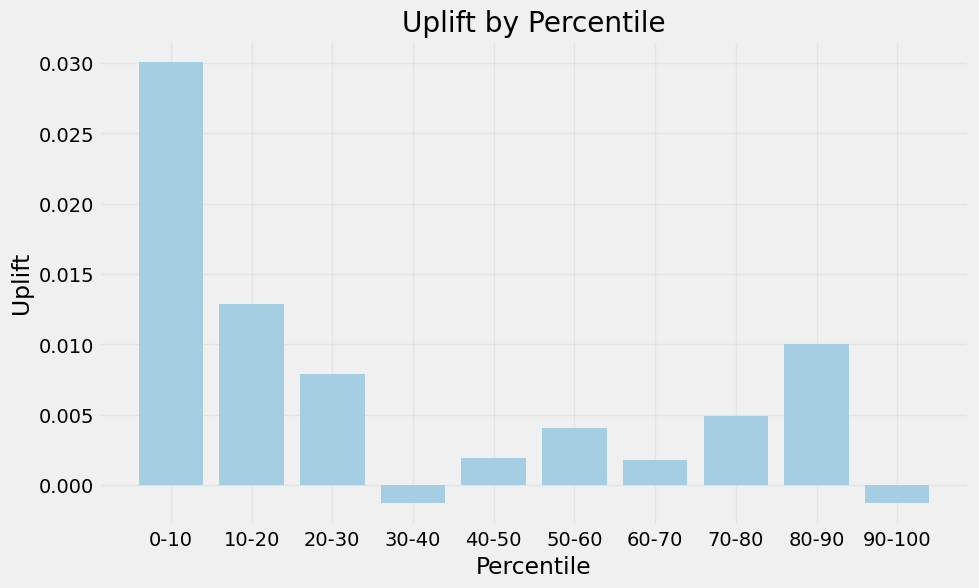

In [65]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v1, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

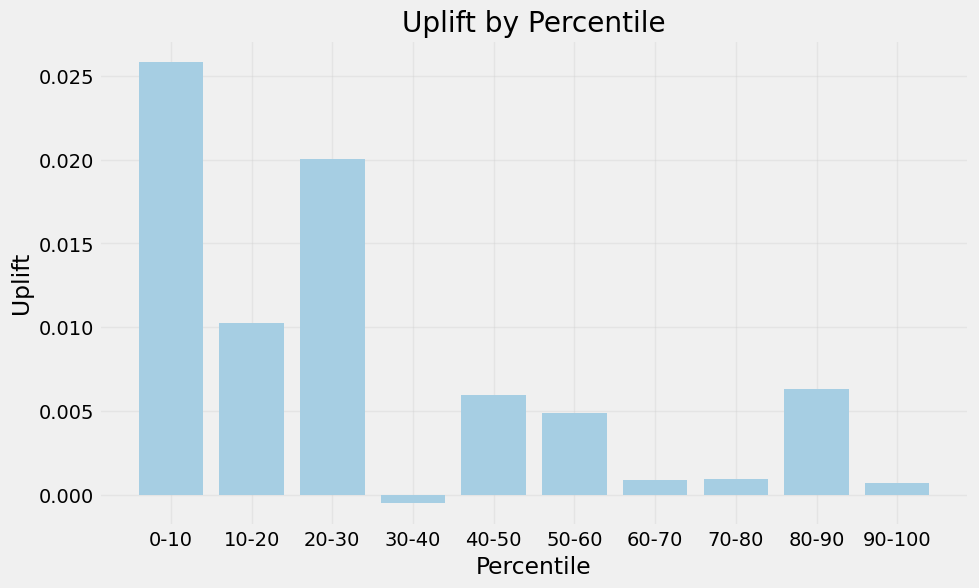

In [66]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v2, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

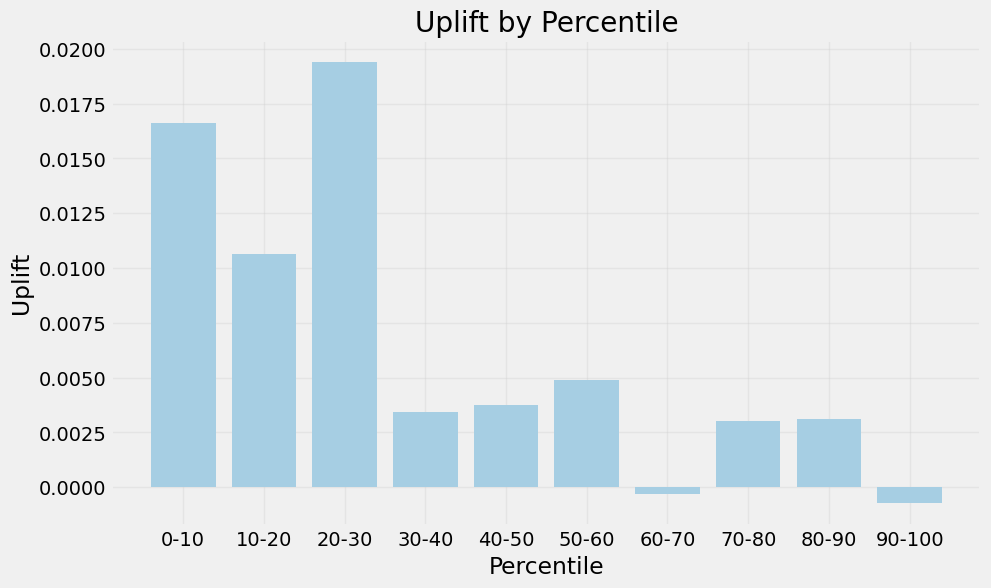

In [67]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v3, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

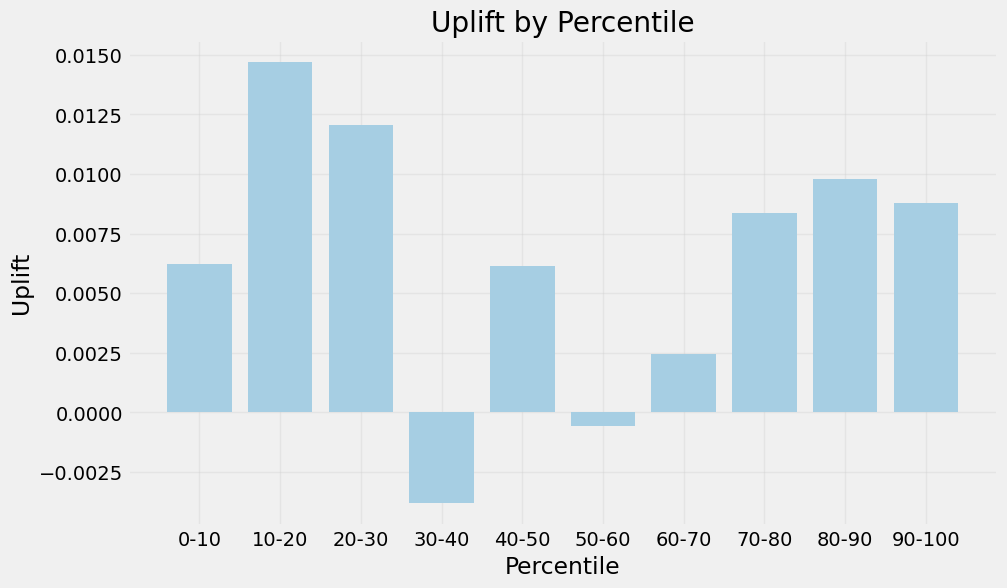

In [68]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v4, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

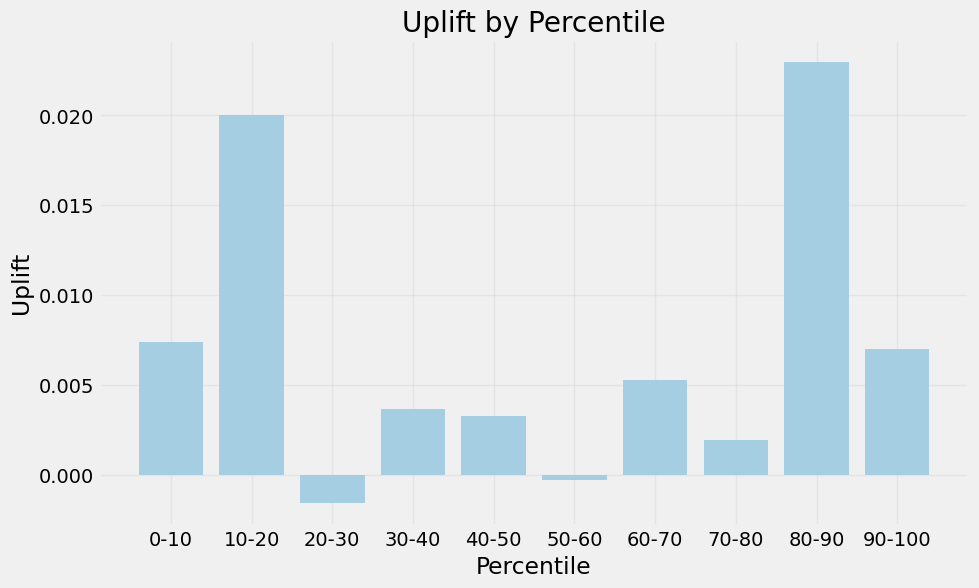

In [69]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v5, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

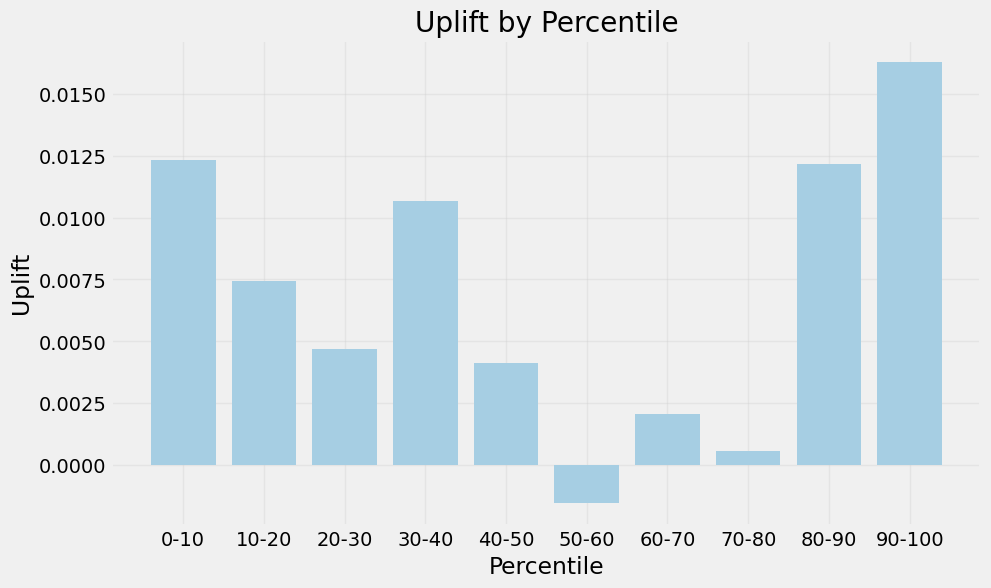

In [70]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v6, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

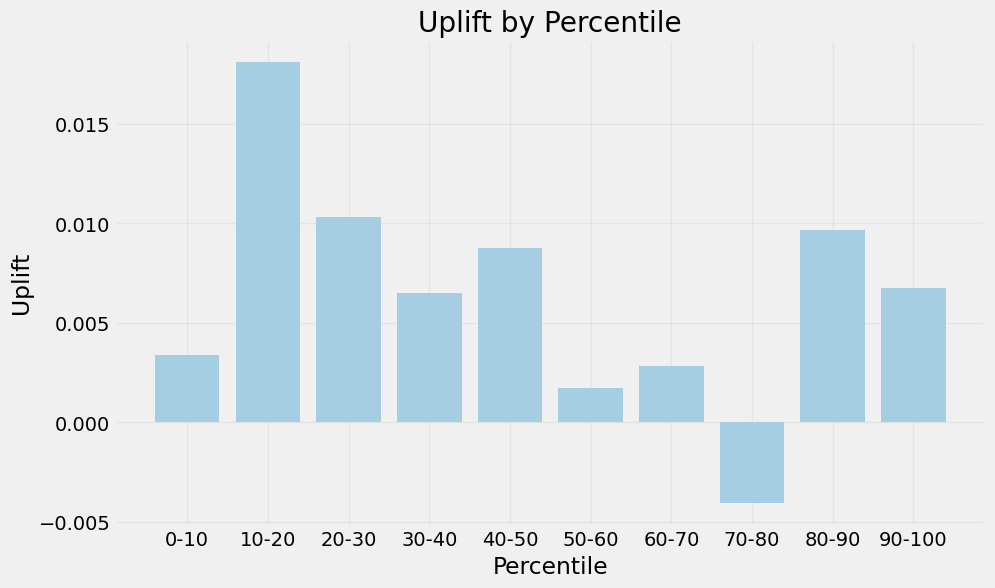

In [71]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v7, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

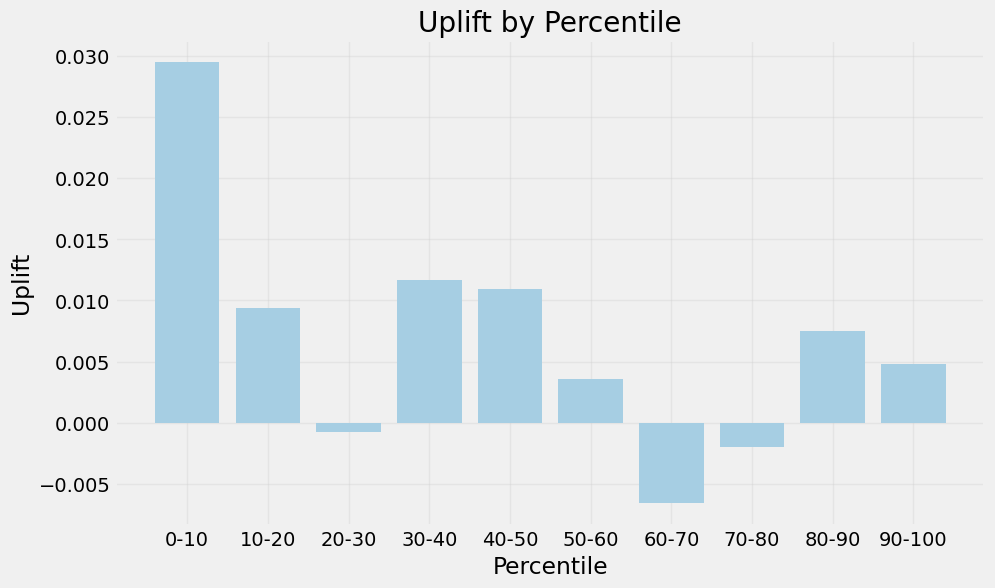

In [72]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v8, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()